In [ ]:
import numpy as np
import pandas as pd
import matplotlib as plt

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

In [2]:
X, y = mnist.data, mnist.target
X, y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 array(['5', '0', '4', ..., '4', '5', '6'], dtype=object))

In [3]:
X.shape

(70000, 784)

In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [7]:
len(X_test)

10000

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(weights="uniform")

In [28]:
knn_clf.fit(X_train, y_train)

KNeighborsClassifier()

In [32]:
knn_clf.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
        "leaf_size": [30, 40, 50],
        "n_neighbors": [3, 4, 5, 6, 10],
        "weights": ["uniform", "distance"]
    },
]

grid_search = GridSearchCV(knn_clf, param_grid, cv=5,
                           scoring="neg_root_mean_squared_error")

grid_search.fit(X_train, y_train)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

best_knn_clf = KNeighborsClassifier(algorithm="auto", n_neighbors=4, weights="distance")
best_knn_clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [15]:
baseline_accuracy = best_knn_clf.score(X_test, y_test)
baseline_accuracy

0.9714

In [19]:
y_pred = best_knn_clf.predict(X_test)

In [21]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_test, y_pred, average="macro")

0.9715597201945959

In [22]:
recall_score(y_test, y_pred, average="macro")

0.9710823052664403

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[ 973,    1,    1,    0,    0,    1,    3,    1,    0,    0],
       [   0, 1132,    2,    0,    0,    0,    1,    0,    0,    0],
       [  10,    5,  995,    2,    1,    0,    0,   16,    3,    0],
       [   0,    1,    3,  974,    1,   14,    1,    7,    4,    5],
       [   1,    5,    0,    0,  950,    0,    4,    3,    0,   19],
       [   4,    0,    0,    9,    2,  862,    7,    1,    3,    4],
       [   4,    2,    0,    0,    3,    3,  946,    0,    0,    0],
       [   0,   17,    4,    0,    3,    0,    0,  994,    0,   10],
       [   5,    2,    4,   14,    5,   11,    4,    4,  920,    5],
       [   3,    4,    2,    7,    9,    4,    1,   10,    1,  968]])

In [24]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

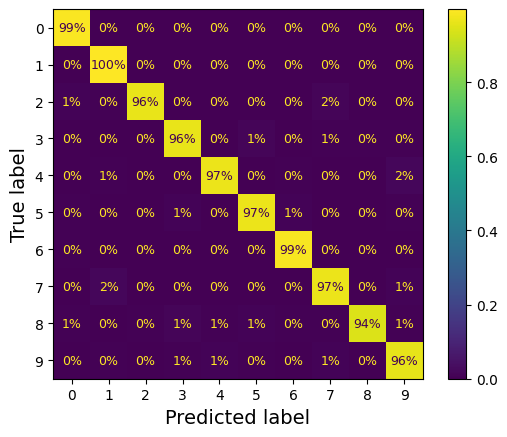

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true", values_format=".0%")
plt.show()

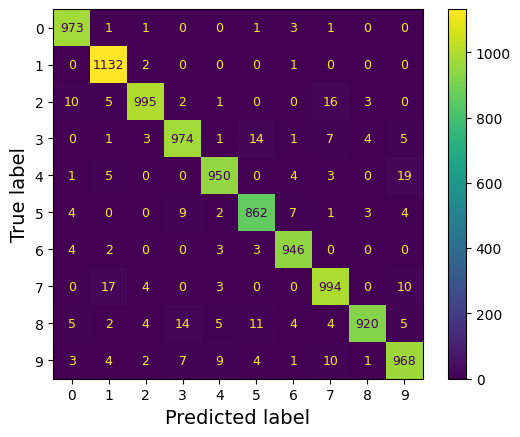

In [26]:
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

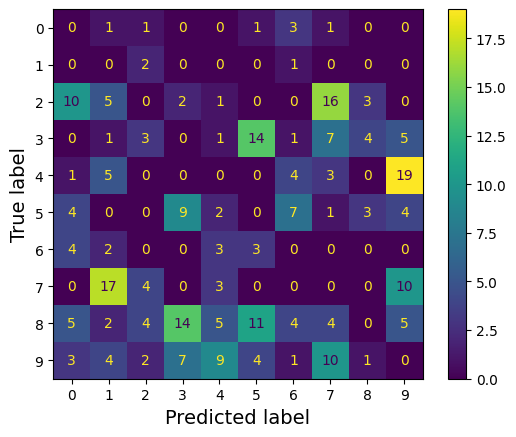

In [28]:
sample_weight = (y_pred != y_test)
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        sample_weight=sample_weight)
plt.show()